# Feature Engineering — Dự báo Nguy cơ Trả hàng (Order Return Prediction)

Notebook này xây dựng **tập đặc trưng hoàn chỉnh** cho bài toán dự đoán trả hàng ở **cấp đơn hàng**.

## Nguyên tắc cốt lõi

| Quy tắc | Giải thích |
| :--- | :--- |
| **Đơn vị dự báo** | `order_id` — 1 đơn hàng |
| **Thời điểm dự báo** | Ngay khi khách bấm Checkout |
| **y=1** | Đơn hàng có **ít nhất 1 sản phẩm** bị trả lại |
| **Dữ liệu KHÔNG được phép** | `ship_date`, `delivery_date`, `return_date`, `return_reason` |
| **Đặc trưng lịch sử** | Tính strictly `order_date < current_order_date` |

## 5 nhóm đặc trưng

1. **Order Composition** — Thành phần đơn hàng (aggregated từ order_items)
2. **Customer Features** — Hành vi lịch sử khách hàng
3. **Channel Features** — Kênh đặt hàng
4. **Temporal Features** — Đặc trưng thời gian
5. **Interaction Features** — Đặc trưng tương tác

## 1. Khởi tạo Môi trường & Tải dữ liệu

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
DATA_DIR = r'./datathon-2026-round-1'
print('Sẵn sàng!')

Sẵn sàng!


In [2]:
# Đọc tất cả bảng dữ liệu
df_orders     = pd.read_csv(os.path.join(DATA_DIR, 'orders.csv'), parse_dates=['order_date'])
df_order_items = pd.read_csv(os.path.join(DATA_DIR, 'order_items.csv'), low_memory=False)
df_returns    = pd.read_csv(os.path.join(DATA_DIR, 'returns.csv'), parse_dates=['return_date'])
df_products   = pd.read_csv(os.path.join(DATA_DIR, 'products.csv'))
df_customers  = pd.read_csv(os.path.join(DATA_DIR, 'customers.csv'), parse_dates=['signup_date'])
df_reviews    = pd.read_csv(os.path.join(DATA_DIR, 'reviews.csv'), parse_dates=['review_date'])
df_geography  = pd.read_csv(os.path.join(DATA_DIR, 'geography.csv'))

print('Tất cả bảng dữ liệu đã được tải thành công!')

Tất cả bảng dữ liệu đã được tải thành công!


## 2. Xây dựng Bảng dữ liệu gốc (Base Dataset)

Tạo bảng dữ liệu ở mức **`order_id`** với biến mục tiêu $y$.

In [3]:
# Lọc đơn hàng đủ điều kiện (delivered/returned)
eligible_statuses = ['delivered', 'returned']
df_eligible = df_orders[df_orders['order_status'].isin(eligible_statuses)].copy()

# Gắn nhãn mục tiêu y ở cấp order
returned_orders = df_returns['order_id'].unique()
df_eligible['is_returned'] = df_eligible['order_id'].isin(returned_orders).astype(int)

# Base dataset = df_eligible (1 dòng = 1 order)
df_base = df_eligible.sort_values('order_date').reset_index(drop=True)

print(f'Base dataset: {df_base.shape[0]:,} orders')
print(f'Return rate: {df_base["is_returned"].mean()*100:.2f}%')
print(f'Date range: {df_base["order_date"].min().date()} → {df_base["order_date"].max().date()}')

Base dataset: 552,858 orders
Return rate: 6.52%
Date range: 2012-07-04 → 2022-12-31


## 3. Nhóm 1: Đặc trưng Thành phần Đơn hàng (Order Composition)

Aggregate thông tin từ `order_items` + `products` lên cấp `order_id`.

In [4]:
# Ghép thông tin sản phẩm vào order_items
df_items = df_order_items.merge(df_products, on='product_id', how='left')
df_items['line_total'] = df_items['quantity'] * df_items['unit_price'] - df_items['discount_amount']
df_items['has_discount'] = (df_items['discount_amount'] > 0).astype(int)
df_items['has_promo'] = df_items['promo_id'].notna().astype(int)

# Size ordinal
size_map = {'S': 1, 'M': 2, 'L': 3, 'XL': 4}
df_items['size_ordinal'] = df_items['size'].map(size_map)

# Margin
df_items['product_margin'] = (df_items['price'] - df_items['cogs']) / df_items['price'].clip(lower=1)

# Aggregate lên cấp order_id
order_agg = df_items.groupby('order_id').agg(
    # Counts
    n_products=('product_id', 'nunique'),
    n_items=('quantity', 'sum'),
    n_categories=('category', 'nunique'),
    n_segments=('segment', 'nunique'),
    n_sizes=('size', 'nunique'),
    n_colors=('color', 'nunique'),
    # Value
    order_total_value=('line_total', 'sum'),
    avg_unit_price=('unit_price', 'mean'),
    max_unit_price=('unit_price', 'max'),
    min_unit_price=('unit_price', 'min'),
    std_unit_price=('unit_price', 'std'),
    # Discount & Promo
    total_discount=('discount_amount', 'sum'),
    avg_discount=('discount_amount', 'mean'),
    has_any_discount=('has_discount', 'max'),
    discount_item_ratio=('has_discount', 'mean'),  # % items có discount
    has_any_promo=('has_promo', 'max'),
    promo_item_ratio=('has_promo', 'mean'),
    # Product attributes
    avg_size_ordinal=('size_ordinal', 'mean'),
    avg_margin=('product_margin', 'mean'),
    max_margin=('product_margin', 'max'),
    min_margin=('product_margin', 'min'),
).reset_index()

# Fill NaN cho std (orders with 1 item)
order_agg['std_unit_price'] = order_agg['std_unit_price'].fillna(0)

# Price range trong đơn
order_agg['price_range'] = order_agg['max_unit_price'] - order_agg['min_unit_price']

# Discount percentage
order_agg['discount_pct'] = order_agg['total_discount'] / (order_agg['order_total_value'] + order_agg['total_discount']).clip(lower=1)

# Merge vào df_base
df_base = df_base.merge(order_agg, on='order_id', how='left')

print(f'Order composition features: {order_agg.shape[1] - 1} features')
print(f'  n_products: mean={df_base["n_products"].mean():.2f}')
print(f'  order_total_value: mean={df_base["order_total_value"].mean():.0f}')

Order composition features: 23 features
  n_products: mean=1.10
  order_total_value: mean=24209


In [5]:
# Dominant category (category chiếm đa số trong đơn)
dominant_cat = df_items.groupby('order_id')['category'].agg(
    lambda x: x.mode().iloc[0] if len(x) > 0 else 'unknown'
).reset_index()
dominant_cat.columns = ['order_id', 'dominant_category']
df_base = df_base.merge(dominant_cat, on='order_id', how='left')

# Dominant segment
dominant_seg = df_items.groupby('order_id')['segment'].agg(
    lambda x: x.mode().iloc[0] if len(x) > 0 else 'unknown'
).reset_index()
dominant_seg.columns = ['order_id', 'dominant_segment']
df_base = df_base.merge(dominant_seg, on='order_id', how='left')

print(f'Dominant category distribution:')
print(df_base['dominant_category'].value_counts().to_string())

Dominant category distribution:
dominant_category
Streetwear    330145
Outdoor       170995
GenZ           31675
Casual         20043


In [6]:
# ===== Historical return rate cho các sản phẩm trong đơn =====
# Tính tỷ lệ return lịch sử của từng product_id, rồi avg lên cấp order
# QUAN TRỌNG: chỉ dùng dữ liệu TRƯỚC thời điểm đơn hiện tại

# Tạo bảng: order_id -> order_date
order_dates = df_base[['order_id', 'order_date']].copy()

# Tạo bảng return history cho mỗi product
# Ghép order_items với order info
items_with_date = df_order_items.merge(order_dates, on='order_id', how='inner')
items_with_date = items_with_date.merge(
    df_returns[['order_id', 'product_id']].drop_duplicates().assign(was_returned=1),
    on=['order_id', 'product_id'], how='left'
)
items_with_date['was_returned'] = items_with_date['was_returned'].fillna(0).astype(int)
items_with_date = items_with_date.sort_values('order_date')

# Cumulative return rate per product (leakage-safe)
items_with_date['prod_cum_returns'] = items_with_date.groupby('product_id')['was_returned'].cumsum()
items_with_date['prod_cum_returns'] = items_with_date.groupby('product_id')['prod_cum_returns'].shift(1).fillna(0)
items_with_date['prod_cum_total'] = items_with_date.groupby('product_id').cumcount()
items_with_date['prod_hist_return_rate'] = items_with_date['prod_cum_returns'] / items_with_date['prod_cum_total'].clip(lower=1)

# Aggregate product historical return rates lên cấp order
order_prod_hist = items_with_date.groupby('order_id').agg(
    avg_prod_hist_return_rate=('prod_hist_return_rate', 'mean'),
    max_prod_hist_return_rate=('prod_hist_return_rate', 'max'),
    sum_prod_hist_returns=('prod_cum_returns', 'sum'),
).reset_index()

df_base = df_base.merge(order_prod_hist, on='order_id', how='left')
for col in ['avg_prod_hist_return_rate', 'max_prod_hist_return_rate', 'sum_prod_hist_returns']:
    df_base[col] = df_base[col].fillna(0)

print('Product historical return features (Leakage-safe):')
print(f'  avg_prod_hist_return_rate: mean={df_base["avg_prod_hist_return_rate"].mean():.4f}')
print(f'  max_prod_hist_return_rate: mean={df_base["max_prod_hist_return_rate"].mean():.4f}')

del items_with_date
gc.collect()

Product historical return features (Leakage-safe):
  avg_prod_hist_return_rate: mean=0.0648
  max_prod_hist_return_rate: mean=0.0654


0

## 4. Nhóm 2: Đặc trưng Khách hàng (Customer Features)

> ⚠️ **Data Leakage Prevention:** Mỗi đặc trưng lịch sử phải dùng `cumsum().shift(1)`.

In [7]:
# Customer Demographics (Static)
df_base = df_base.merge(
    df_customers[['customer_id', 'signup_date', 'gender', 'age_group', 'acquisition_channel']],
    on='customer_id', how='left'
)

# Customer tenure tại thời điểm đặt hàng
df_base['customer_tenure_days'] = (df_base['order_date'] - df_base['signup_date']).dt.days
df_base['customer_tenure_days'] = df_base['customer_tenure_days'].clip(lower=0)

print('Customer demographics merged!')
print(f'  Gender: {df_base["gender"].value_counts().to_dict()}')

Customer demographics merged!
  Gender: {'Female': 270999, 'Male': 260573, 'Non-binary': 21286}


In [8]:
# Customer order number (thứ tự đơn hàng)
df_base = df_base.sort_values(['customer_id', 'order_date']).reset_index(drop=True)
df_base['customer_order_number'] = df_base.groupby('customer_id').cumcount() + 1
df_base['is_first_order'] = (df_base['customer_order_number'] == 1).astype(int)

print(f'Customer order number: min={df_base["customer_order_number"].min()}, '
      f'max={df_base["customer_order_number"].max()}, '
      f'median={df_base["customer_order_number"].median()}')
print(f'First orders: {df_base["is_first_order"].sum():,} ({df_base["is_first_order"].mean()*100:.1f}%)')

Customer order number: min=1, max=97, median=5.0
First orders: 86,691 (15.7%)


In [9]:
# Customer historical return rate & count (Leakage-safe)
df_base = df_base.sort_values(['customer_id', 'order_date']).reset_index(drop=True)

# Cumulative returns per customer (shift 1 to exclude current)
df_base['cust_cum_returns'] = df_base.groupby('customer_id')['is_returned'].cumsum()
df_base['cust_cum_returns'] = df_base.groupby('customer_id')['cust_cum_returns'].shift(1).fillna(0)
df_base['cust_cum_orders'] = df_base.groupby('customer_id').cumcount()  # = order_number - 1

df_base['customer_return_rate'] = df_base['cust_cum_returns'] / df_base['cust_cum_orders'].clip(lower=1)
df_base['customer_return_count'] = df_base['cust_cum_returns']
df_base['customer_total_orders_before'] = df_base['cust_cum_orders']

# Clean up
df_base.drop(columns=['cust_cum_returns', 'cust_cum_orders'], inplace=True)

print('Customer historical return features (Leakage-safe):')
print(f'  customer_return_rate: mean={df_base["customer_return_rate"].mean():.4f}')
print(f'  customer_return_count: mean={df_base["customer_return_count"].mean():.2f}')

Customer historical return features (Leakage-safe):
  customer_return_rate: mean=0.0549
  customer_return_count: mean=0.46


In [10]:
# Customer recency — Số ngày kể từ đơn hàng gần nhất
df_base = df_base.sort_values(['customer_id', 'order_date'])
df_base['prev_order_date'] = df_base.groupby('customer_id')['order_date'].shift(1)
df_base['customer_recency_days'] = (df_base['order_date'] - df_base['prev_order_date']).dt.days
df_base['customer_recency_days'] = df_base['customer_recency_days'].fillna(-1)  # First order = -1
df_base.drop(columns=['prev_order_date'], inplace=True)

# Customer average order value (historical)
df_base = df_base.sort_values(['customer_id', 'order_date'])
df_base['cust_cum_spending'] = df_base.groupby('customer_id')['order_total_value'].cumsum()
df_base['cust_cum_spending'] = df_base.groupby('customer_id')['cust_cum_spending'].shift(1).fillna(0)
df_base['cust_cum_cnt'] = df_base.groupby('customer_id').cumcount()
df_base['customer_avg_order_value'] = df_base['cust_cum_spending'] / df_base['cust_cum_cnt'].clip(lower=1)
df_base['customer_avg_order_value'] = df_base['customer_avg_order_value'].fillna(0)
df_base.drop(columns=['cust_cum_spending', 'cust_cum_cnt'], inplace=True)

print(f'customer_recency_days: mean={df_base[df_base["customer_recency_days"] >= 0]["customer_recency_days"].mean():.1f} days')
print(f'customer_avg_order_value: mean={df_base["customer_avg_order_value"].mean():.2f}')

customer_recency_days: mean=312.7 days
customer_avg_order_value: mean=19226.16


## 5. Nhóm 3: Đặc trưng Kênh đặt hàng (Channel Features)

Thông tin biết được tại thời điểm checkout: `payment_method`, `device_type`, `order_source`.

In [11]:
# Các cột này đã có sẵn trong df_base từ bảng orders
# Chỉ cần thêm Region
df_base = df_base.merge(df_geography[['zip', 'region']], on='zip', how='left')

print('Channel features available:')
print(f'  payment_method: {df_base["payment_method"].nunique()} values')
print(f'  device_type: {df_base["device_type"].nunique()} values')
print(f'  order_source: {df_base["order_source"].nunique()} values')
print(f'  region: {df_base["region"].nunique()} values')

Channel features available:
  payment_method: 5 values
  device_type: 3 values
  order_source: 6 values
  region: 3 values


## 6. Nhóm 4: Đặc trưng Thời gian (Temporal Features)

In [12]:
# Calendar features
df_base['order_month'] = df_base['order_date'].dt.month
df_base['order_day_of_week'] = df_base['order_date'].dt.dayofweek
df_base['order_day_of_year'] = df_base['order_date'].dt.dayofyear
df_base['is_weekend'] = df_base['order_day_of_week'].isin([5, 6]).astype(int)
df_base['order_quarter'] = df_base['order_date'].dt.quarter
df_base['order_year'] = df_base['order_date'].dt.year

# Cyclical encoding
df_base['month_sin'] = np.sin(2 * np.pi * df_base['order_month'] / 12)
df_base['month_cos'] = np.cos(2 * np.pi * df_base['order_month'] / 12)
df_base['dow_sin'] = np.sin(2 * np.pi * df_base['order_day_of_week'] / 7)
df_base['dow_cos'] = np.cos(2 * np.pi * df_base['order_day_of_week'] / 7)

print('Temporal features created!')

Temporal features created!


## 7. Nhóm 5: Đặc trưng Tương tác (Interaction Features)

In [13]:
# 1. Customer average rating (tổng hợp tất cả reviews trước đó)
# df_reviews đã có customer_id, chỉ cần lấy thêm order_date
reviews_with_date = df_reviews.merge(
    df_eligible[['order_id', 'order_date']],
    on='order_id', how='inner'
)

# Lấy overall avg rating per customer (simplified — dùng toàn bộ lịch sử)
cust_avg_rating = reviews_with_date.groupby('customer_id').agg(
    customer_avg_rating=('rating', 'mean'),
    customer_review_count=('rating', 'count')
).reset_index()

df_base = df_base.merge(cust_avg_rating, on='customer_id', how='left')
df_base['customer_avg_rating'] = df_base['customer_avg_rating'].fillna(0)
df_base['customer_review_count'] = df_base['customer_review_count'].fillna(0)
df_base['has_reviewed'] = (df_base['customer_review_count'] > 0).astype(int)

print(f'Customer avg rating: {df_base["customer_avg_rating"].mean():.2f}')
print(f'Customers with reviews: {df_base["has_reviewed"].mean()*100:.1f}%')

Customer avg rating: 3.27
Customers with reviews: 83.0%


In [14]:
# 2. Category/Region global return rates
cat_return_rate = df_base.groupby('dominant_category')['is_returned'].mean().reset_index()
cat_return_rate.columns = ['dominant_category', 'category_global_return_rate']
df_base = df_base.merge(cat_return_rate, on='dominant_category', how='left')

region_return_rate = df_base.groupby('region')['is_returned'].mean().reset_index()
region_return_rate.columns = ['region', 'region_global_return_rate']
df_base = df_base.merge(region_return_rate, on='region', how='left')

# 3. Payment method return rate
pay_return_rate = df_base.groupby('payment_method')['is_returned'].mean().reset_index()
pay_return_rate.columns = ['payment_method', 'payment_global_return_rate']
df_base = df_base.merge(pay_return_rate, on='payment_method', how='left')

print('Interaction features created!')
print(f'  category_global_return_rate: mean={df_base["category_global_return_rate"].mean():.4f}')
print(f'  region_global_return_rate: mean={df_base["region_global_return_rate"].mean():.4f}')

Interaction features created!
  category_global_return_rate: mean=0.0652
  region_global_return_rate: mean=0.0652


## 8. Tổng kết Đặc trưng & Lưu Dataset

In [15]:
# Danh sách features
ID_COLS = ['order_id', 'order_date', 'customer_id']
TARGET_COL = 'is_returned'

CATEGORICAL_FEATURES = [
    'payment_method', 'device_type', 'order_source',
    'gender', 'age_group', 'acquisition_channel', 'region',
    'dominant_category', 'dominant_segment'
]

NUMERIC_FEATURES = [
    # Order composition
    'n_products', 'n_items', 'n_categories', 'n_segments', 'n_sizes', 'n_colors',
    'order_total_value', 'avg_unit_price', 'max_unit_price', 'min_unit_price', 'std_unit_price',
    'total_discount', 'avg_discount', 'has_any_discount', 'discount_item_ratio', 'discount_pct',
    'has_any_promo', 'promo_item_ratio',
    'avg_size_ordinal', 'avg_margin', 'max_margin', 'min_margin', 'price_range',
    'avg_prod_hist_return_rate', 'max_prod_hist_return_rate', 'sum_prod_hist_returns',
    # Customer features
    'customer_tenure_days', 'customer_order_number', 'is_first_order',
    'customer_return_rate', 'customer_return_count', 'customer_total_orders_before',
    'customer_recency_days', 'customer_avg_order_value',
    # Temporal features
    'order_month', 'order_day_of_week', 'is_weekend', 'order_quarter', 'order_year',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    # Interaction features
    'customer_avg_rating', 'customer_review_count', 'has_reviewed',
    'category_global_return_rate', 'region_global_return_rate', 'payment_global_return_rate',
]

print(f'=== TỔNG KẾT ĐẶC TRƯNG ===')
print(f'  Categorical features: {len(CATEGORICAL_FEATURES)}')
print(f'  Numeric features: {len(NUMERIC_FEATURES)}')
print(f'  Total features: {len(CATEGORICAL_FEATURES) + len(NUMERIC_FEATURES)}')
print(f'\nDataset shape: {df_base.shape}')

=== TỔNG KẾT ĐẶC TRƯNG ===
  Categorical features: 9
  Numeric features: 49
  Total features: 58

Dataset shape: (552858, 66)


In [16]:
# Kiểm tra missing values
missing_info = df_base[NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET_COL]].isnull().sum()
missing_info = missing_info[missing_info > 0].sort_values(ascending=False)

if len(missing_info) > 0:
    print('=== CÁC CỘT CÓ MISSING VALUES ===')
    for col, count in missing_info.items():
        print(f'  {col}: {count:,} ({count/len(df_base)*100:.2f}%)')
else:
    print('Không có missing values trong các cột features! ✅')

Không có missing values trong các cột features! ✅


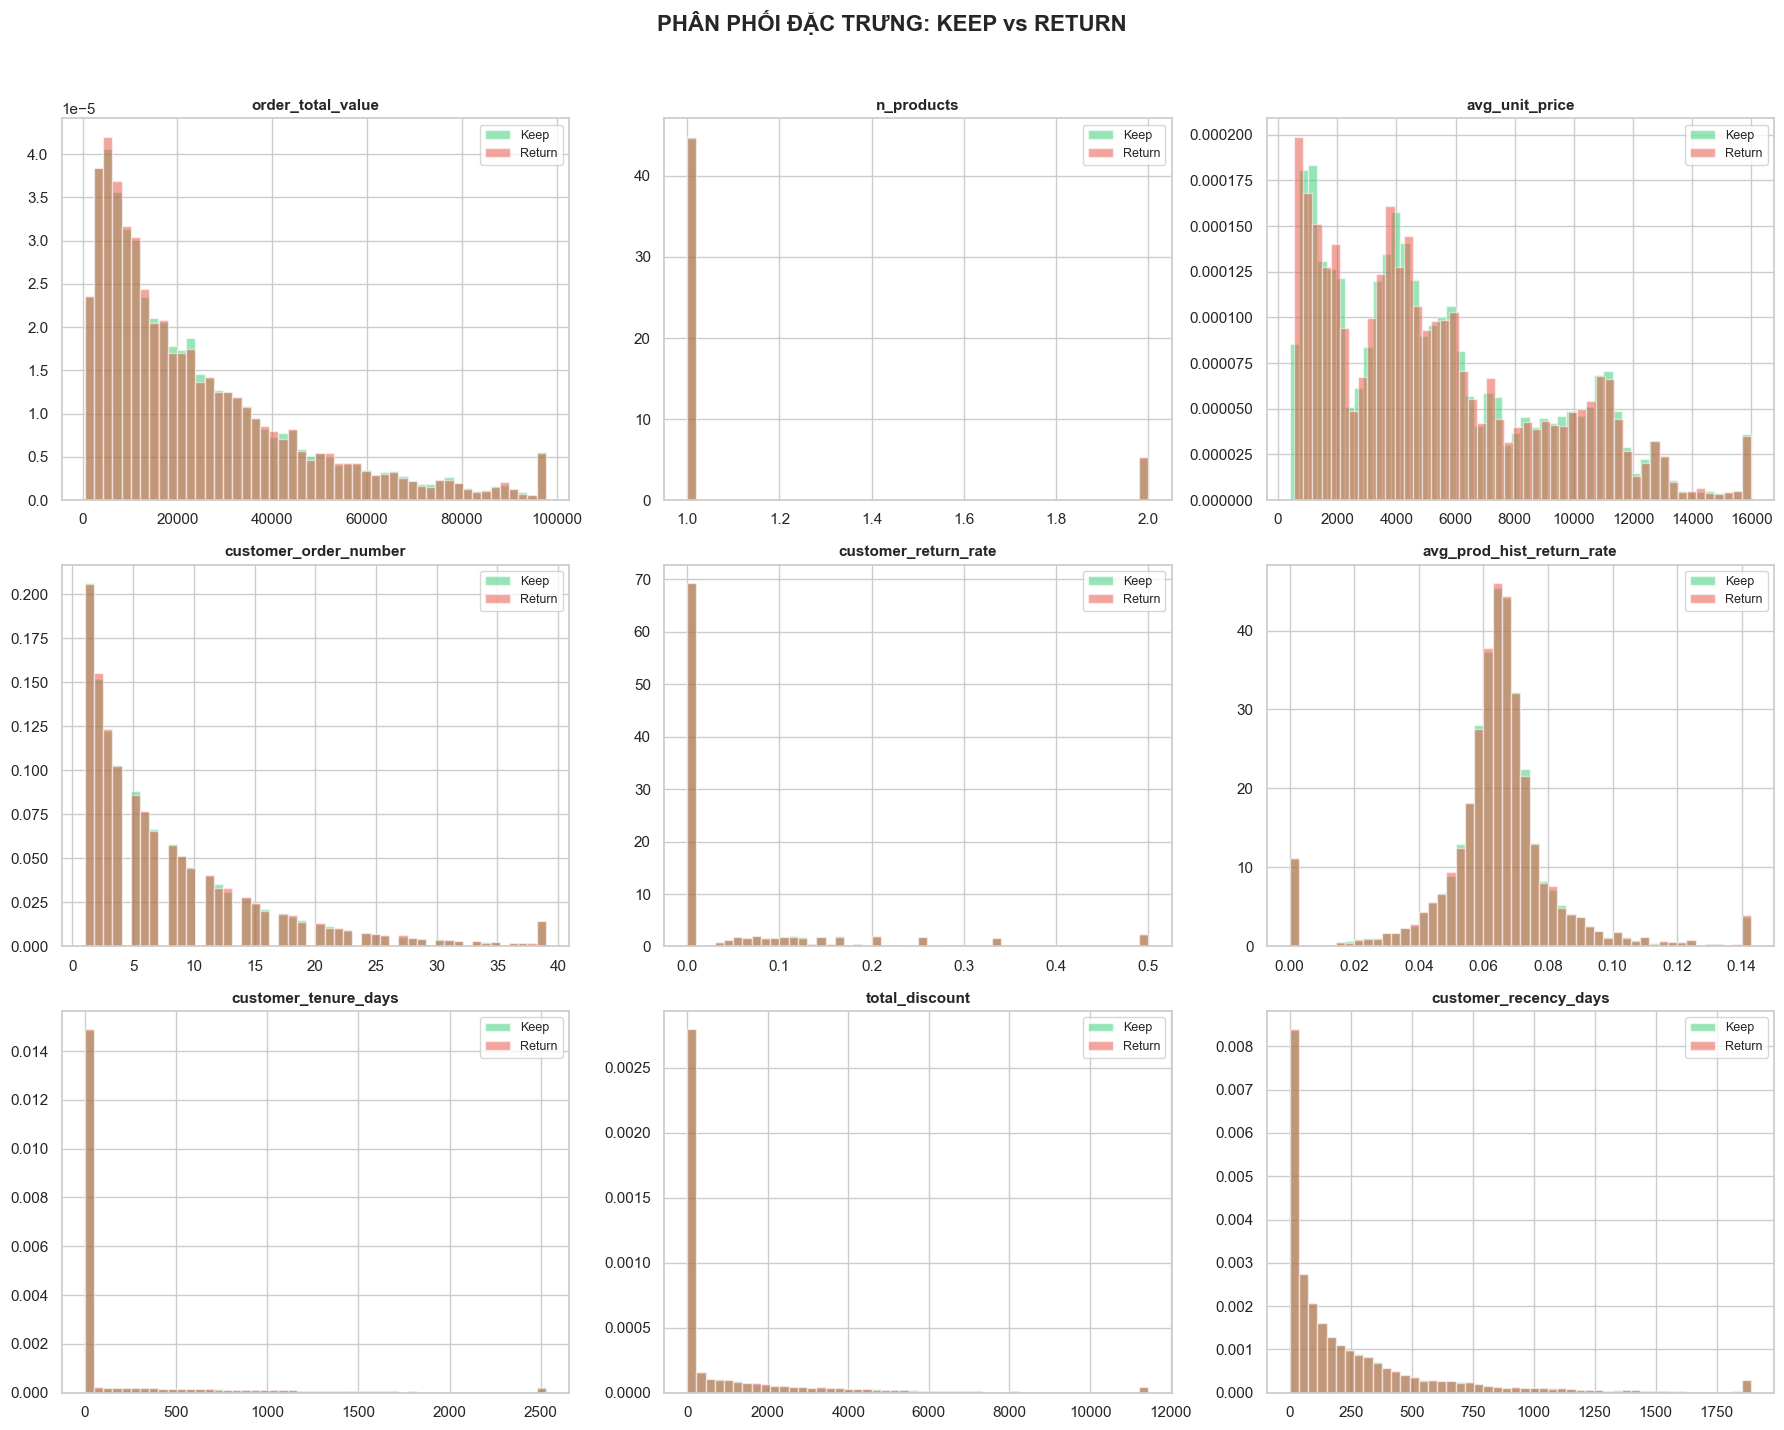

In [17]:
# Trực quan hóa phân phối đặc trưng quan trọng
key_features = [
    'order_total_value', 'n_products', 'avg_unit_price',
    'customer_order_number', 'customer_return_rate',
    'avg_prod_hist_return_rate', 'customer_tenure_days',
    'total_discount', 'customer_recency_days'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    if i >= 9:
        break
    data_keep = df_base[df_base['is_returned'] == 0][feat].dropna()
    data_ret = df_base[df_base['is_returned'] == 1][feat].dropna()
    clip_val = df_base[feat].quantile(0.99)
    axes[i].hist(data_keep.clip(upper=clip_val), bins=50, alpha=0.5, color='#2ecc71', label='Keep', density=True)
    axes[i].hist(data_ret.clip(upper=clip_val), bins=50, alpha=0.5, color='#e74c3c', label='Return', density=True)
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=9)

plt.suptitle('PHÂN PHỐI ĐẶC TRƯNG: KEEP vs RETURN', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Temporal Train/Test Split

- **Train:** Đơn hàng trước 01/07/2022
- **Test:** Đơn hàng từ 01/07/2022

In [18]:
CUTOFF_DATE = pd.to_datetime('2022-07-01')

df_train = df_base[df_base['order_date'] < CUTOFF_DATE]
df_test = df_base[df_base['order_date'] >= CUTOFF_DATE]

print(f'=== TEMPORAL SPLIT ===')
print(f'Cutoff date: {CUTOFF_DATE.date()}')
print(f'\nTrain: {df_train.shape[0]:,} orders ({df_train["is_returned"].mean()*100:.2f}% return)')
print(f'Test:  {df_test.shape[0]:,} orders ({df_test["is_returned"].mean()*100:.2f}% return)')

=== TEMPORAL SPLIT ===
Cutoff date: 2022-07-01

Train: 540,277 orders (6.52% return)
Test:  12,581 orders (6.61% return)


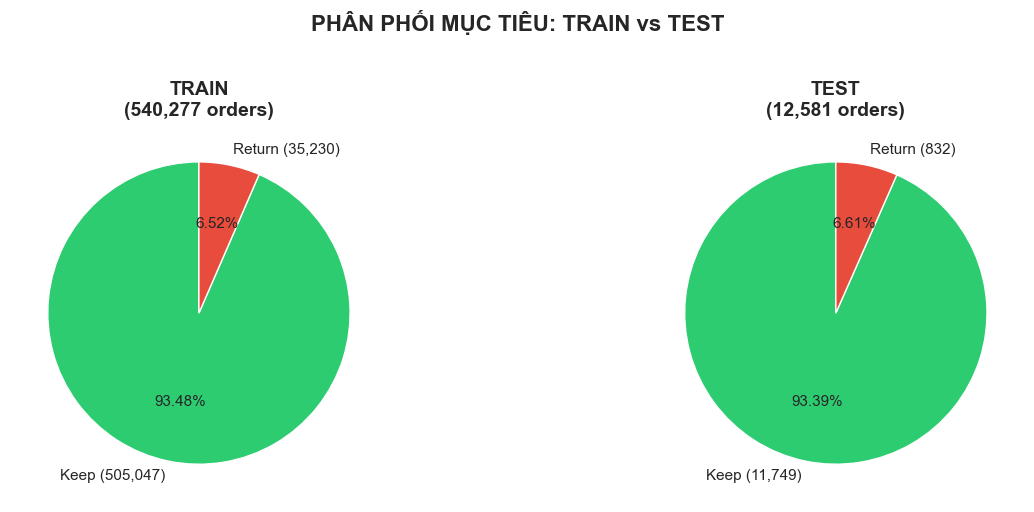

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in [(axes[0], df_train, 'TRAIN'), (axes[1], df_test, 'TEST')]:
    sizes = [df['is_returned'].value_counts()[0], df['is_returned'].value_counts()[1]]
    labels = [f'Keep ({sizes[0]:,})', f'Return ({sizes[1]:,})']
    ax.pie(sizes, labels=labels, colors=['#2ecc71', '#e74c3c'],
           autopct='%1.2f%%', startangle=90, textprops={'fontsize': 11})
    ax.set_title(f'{title}\n({df.shape[0]:,} orders)', fontsize=14, fontweight='bold')

plt.suptitle('PHÂN PHỐI MỤC TIÊU: TRAIN vs TEST', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 10. Lưu Dataset

In [20]:
import json

save_cols = ID_COLS + NUMERIC_FEATURES + CATEGORICAL_FEATURES + [TARGET_COL]
save_cols = [c for c in save_cols if c in df_base.columns]

df_base[save_cols].to_csv(os.path.join(DATA_DIR, 'return_prediction_features.csv'), index=False)
print(f'Đã lưu return_prediction_features.csv ({df_base.shape[0]:,} rows × {len(save_cols)} cols)')

feature_config = {
    'id_columns': ID_COLS,
    'target_column': TARGET_COL,
    'numeric_features': NUMERIC_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'cutoff_date': '2022-07-01',
    'total_features': len(NUMERIC_FEATURES) + len(CATEGORICAL_FEATURES),
    'granularity': 'order_id'
}
with open(os.path.join(DATA_DIR, 'return_prediction_feature_config.json'), 'w') as f:
    json.dump(feature_config, f, indent=2)

print(f'\nĐã lưu return_prediction_feature_config.json')
print(f'  Total: {feature_config["total_features"]} features')

Đã lưu return_prediction_features.csv (552,858 rows × 62 cols)

Đã lưu return_prediction_feature_config.json
  Total: 58 features


## 11. Kết luận

### Bước tiếp theo:
- Sử dụng `return_prediction_features.csv` trong notebook modeling
- Huấn luyện LightGBM/XGBoost với Temporal Split
- Đánh giá bằng AUC-ROC và F1-Score